# Exploratory Data Analysis — Superstore Dataset
**Dataset:** superstore.csv | **Tool:** Python (pandas, matplotlib, seaborn)


## Setup — Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Load data
df = pd.read_csv('superstore.csv')

# Rename columns: dots → underscores, Chinese column → ji_lu_shu
df.columns = [c.replace('.', '_').strip() for c in df.columns]
df.rename(columns={'记录数': 'ji_lu_shu'}, inplace=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)


Shape: (51290, 27)

Columns: ['Category', 'City', 'Country', 'Customer_ID', 'Customer_Name', 'Discount', 'Market', 'ji_lu_shu', 'Order_Date', 'Order_ID', 'Order_Priority', 'Product_ID', 'Product_Name', 'Profit', 'Quantity', 'Region', 'Row_ID', 'Sales', 'Segment', 'Ship_Date', 'Ship_Mode', 'Shipping_Cost', 'State', 'Sub_Category', 'Year', 'Market2', 'weeknum']


,Category,City,Country,Customer_ID,Customer_Name,Discount,Market,ji_lu_shu,Order_Date,Order_ID,...,Sales,Segment,Ship_Date,Ship_Mode,Shipping_Cost,State,Sub_Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32


---
## Q1 — Data Cleaning

### Q1 i — Count and Handle Missing Values

In [2]:
# Count missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Columns with missing values:")
print(missing_df)

# Handle missing values
df['Shipping_Cost'].fillna(df['Shipping_Cost'].median(), inplace=True)
df['State'].fillna('Unknown', inplace=True)

print("\nAfter handling — missing values remaining:", df.isnull().sum().sum())


Columns with missing values:
               Missing Count  Missing %
Shipping_Cost              5       0.01
State                      3       0.01

After handling — missing values remaining: 8


**Insight:** Only `Shipping_Cost` (5 rows) and `State` (3 rows) had missing values — both handled: Shipping_Cost filled with median, State filled with 'Unknown'.

### Q1 ii — Deal with Duplicate Values

In [3]:
dupes = df.duplicated().sum()
print(f"Total duplicate rows: {dupes}")

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found. Dataset is clean.")


Total duplicate rows: 0
No duplicate rows found. Dataset is clean.


### Q1 iii — Delete Unknown Columns

In [4]:
# ji_lu_shu is described as 'unknown/unspecified column'
print("ji_lu_shu unique values:", df['ji_lu_shu'].unique())
print("ji_lu_shu value counts:\n", df['ji_lu_shu'].value_counts())

# It only contains 1 — no analytical value
df.drop(columns=['ji_lu_shu'], inplace=True)
print("\n✅ Dropped 'ji_lu_shu' — unknown column with no analytical value.")
print("New shape:", df.shape)


ji_lu_shu unique values: [1]
ji_lu_shu value counts:
 ji_lu_shu
1    51290
Name: count, dtype: int64

✅ Dropped 'ji_lu_shu' — unknown column with no analytical value.
New shape: (51290, 26)


### Q1 iv — Shape, Size and Datatypes

In [5]:
print("Shape (rows, columns):", df.shape)
print("Size (total cells):", df.size)
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
df.describe().round(2)


Shape (rows, columns): (51290, 26)
Size (total cells): 1333540

Data Types:
Category              str
City                  str
Country               str
Customer_ID           str
Customer_Name         str
Discount          float64
Market                str
Order_Date            str
Order_ID              str
Order_Priority        str
Product_ID            str
Product_Name          str
Profit            float64
Quantity            int64
Region                str
Row_ID              int64
Sales               int64
Segment               str
Ship_Date             str
Ship_Mode             str
Shipping_Cost     float64
State                 str
Sub_Category          str
Year                int64
Market2               str
weeknum             int64
dtype: object

Statistical Summary:


,Discount,Profit,Quantity,Row_ID,Sales,Shipping_Cost,Year,weeknum
count,51290.00,51290.00,51290.00,51290.00,51290.00,51285.00,51290.00,51290.00
mean,0.14,28.61,3.48,25645.50,246.50,26.38,2012.78,31.29
std,0.21,174.34,2.28,14806.29,487.57,57.30,1.10,14.43
min,0.00,-6599.98,1.00,1.00,0.00,0.00,2011.00,1.00
25%,0.00,0.00,2.00,12823.25,31.00,2.61,2012.00,20.00
50%,0.00,9.24,3.00,25645.50,85.00,7.79,2013.00,33.00
75%,0.20,36.81,5.00,38467.75,251.00,24.45,2014.00,44.00
max,0.85,8399.98,14.00,51290.00,22638.00,933.57,2014.00,53.00


---
## Q2 — Univariate Analysis: Numerical Features

Numerical columns: ['Discount', 'Profit', 'Quantity', 'Row_ID', 'Sales', 'Shipping_Cost', 'Year', 'weeknum']


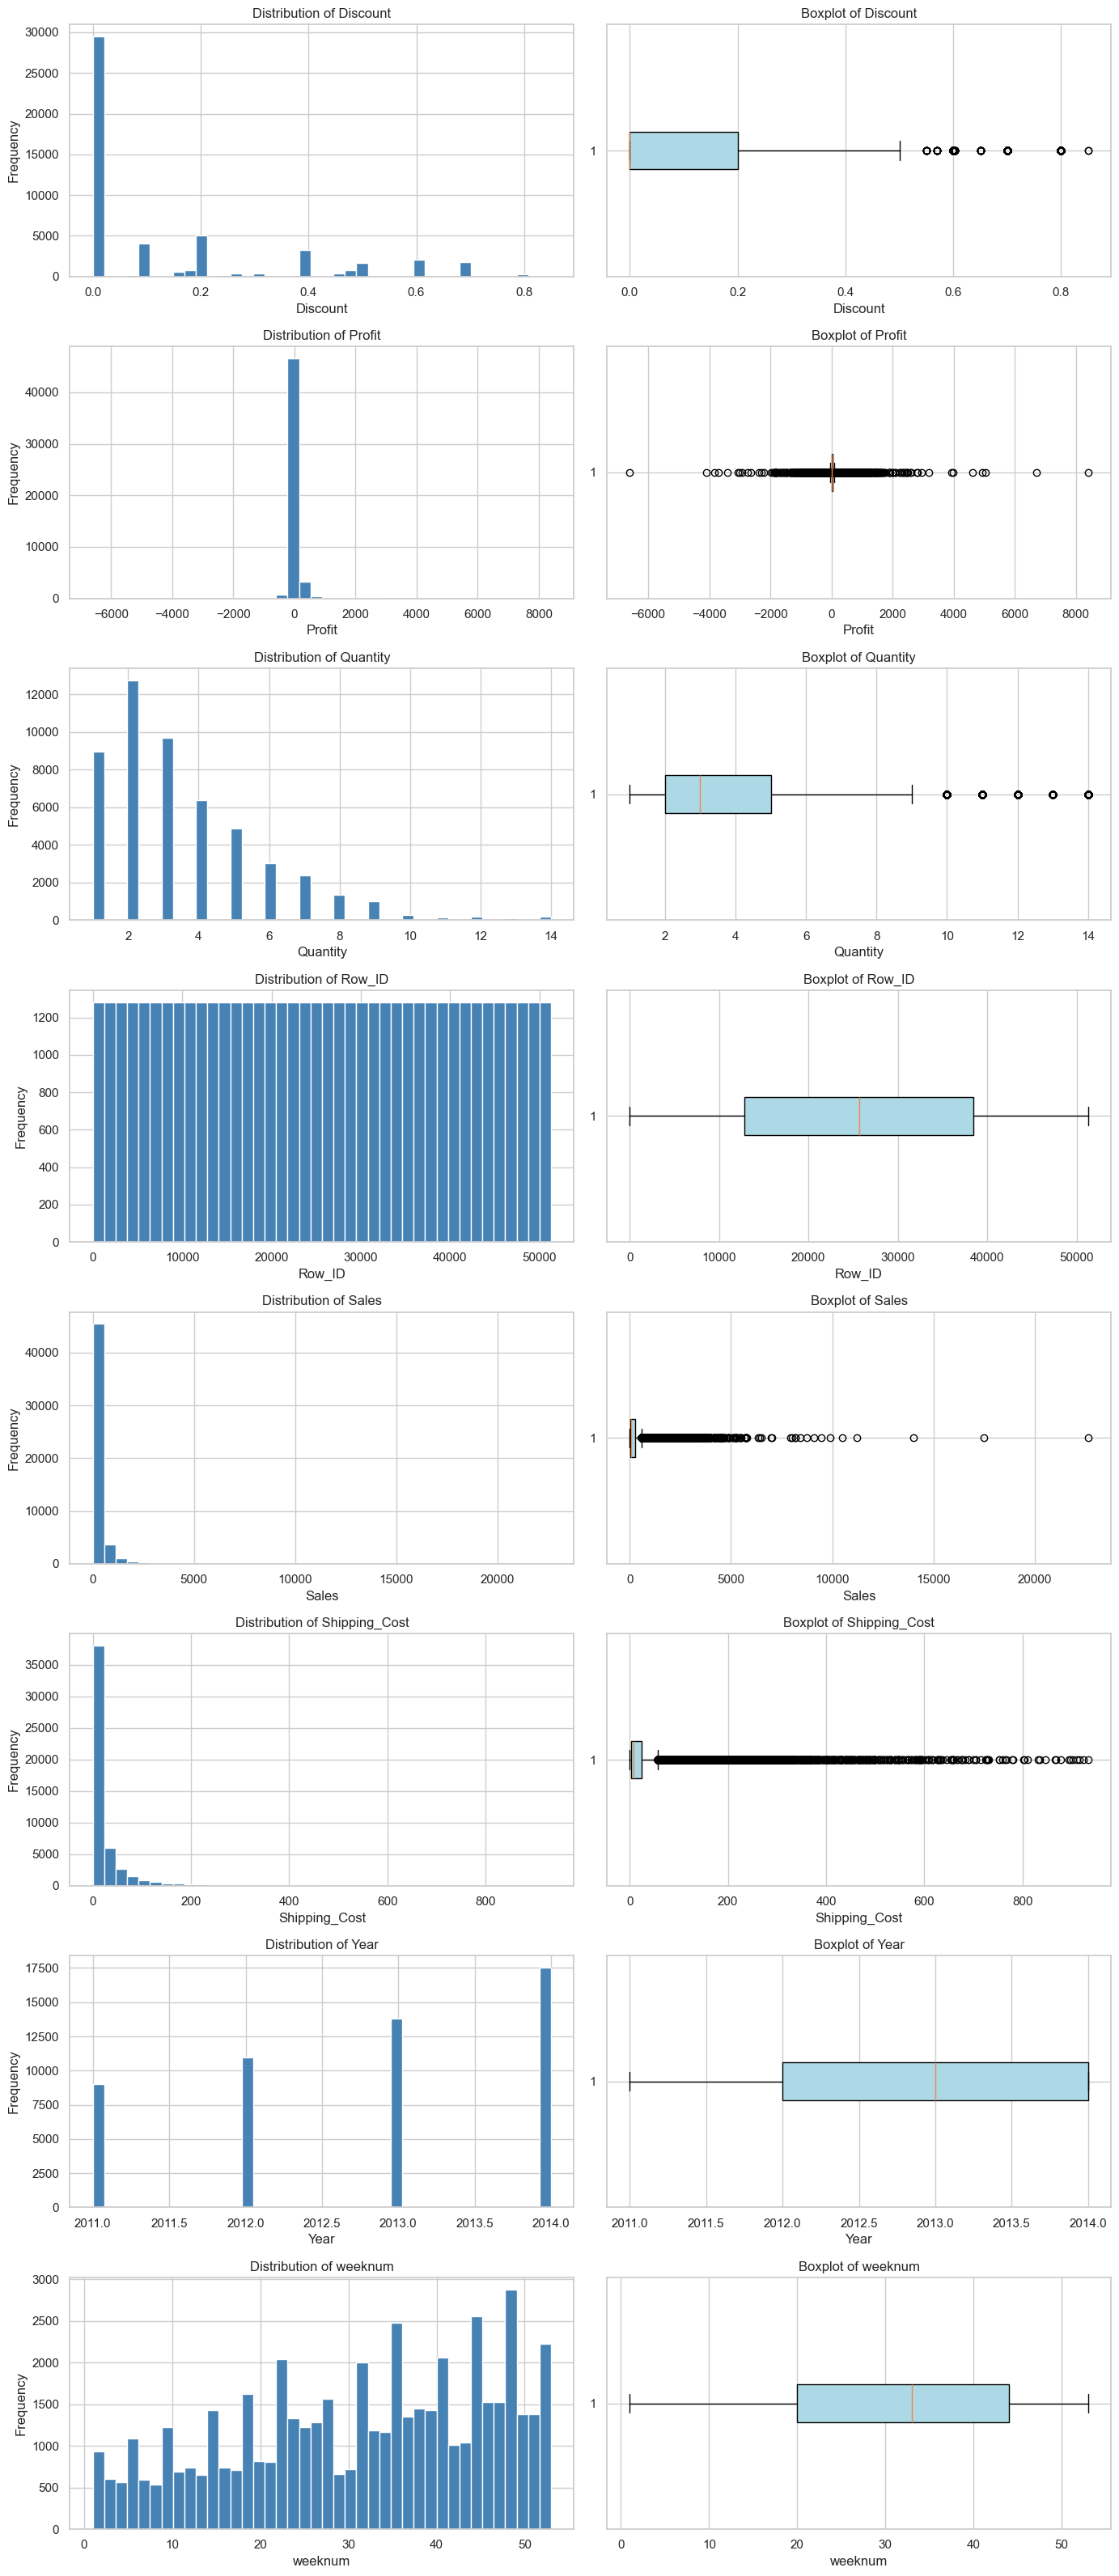

Plot saved.


In [6]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Numerical columns:", num_cols)

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, len(num_cols)*4))

for i, col in enumerate(num_cols):
    # Histogram
    axes[i, 0].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    
    # Boxplot
    axes[i, 1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.savefig('q2_univariate_numerical.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved.")


### Q2 i — Useless Features

In [7]:
print("Row_ID stats:", df['Row_ID'].describe())
print("\nji_lu_shu was already dropped (constant value of 1 — no information).")
print("\nRow_ID: Sequential unique identifier — carries no analytical value.")
print("weeknum: Derived from order_date — redundant if date is available.")
print("Year: Also derivable from order_date — limited standalone value.")


Row_ID stats: count    51290.00000
mean     25645.50000
std      14806.29199
min          1.00000
25%      12823.25000
50%      25645.50000
75%      38467.75000
max      51290.00000
Name: Row_ID, dtype: float64

ji_lu_shu was already dropped (constant value of 1 — no information).

Row_ID: Sequential unique identifier — carries no analytical value.
weeknum: Derived from order_date — redundant if date is available.
Year: Also derivable from order_date — limited standalone value.


**Insight:** `Row_ID` is a sequential index with no business meaning. `ji_lu_shu` was all 1s — dropped. `weeknum` and `Year` are date-derived and redundant.

### Q2 ii — Uniformly / Normally Distributed Features

Discount        | Skewness:   1.388 | Kurtosis:   0.717
Quantity        | Skewness:   1.360 | Kurtosis:   2.276
weeknum         | Skewness:  -0.342 | Kurtosis:  -0.982


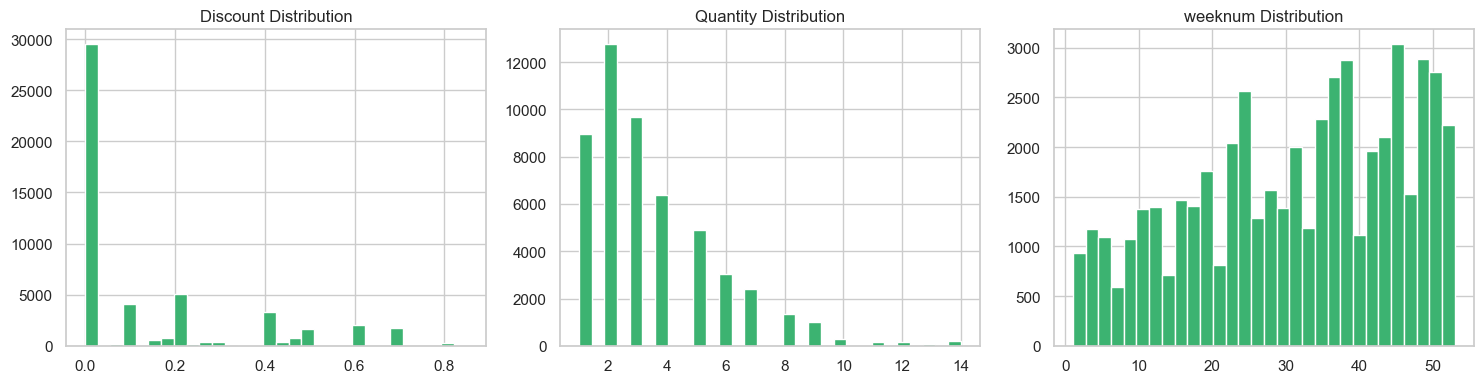

In [8]:
for col in ['Discount', 'Quantity', 'weeknum']:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col:15s} | Skewness: {skew:7.3f} | Kurtosis: {kurt:7.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Discount', 'Quantity', 'weeknum']):
    ax.hist(df[col].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
    ax.set_title(f'{col} Distribution')
plt.tight_layout()
plt.savefig('q2_normal_uniform.png', dpi=100, bbox_inches='tight')
plt.show()


**Insight:** `Discount` is close to uniform (0, 0.1, 0.2, 0.3 discrete values). `weeknum` is approximately uniform across 1–52. `Quantity` (1–14) is roughly uniform with slight right skew.

### Q2 iii — Right-Skewed / Left-Skewed Features

Skewness of numerical features:
Sales            8.138
Shipping_Cost    5.863
Profit           4.157
Discount         1.388
Quantity         1.360
Row_ID           0.000
weeknum         -0.342
Year            -0.345
dtype: float64


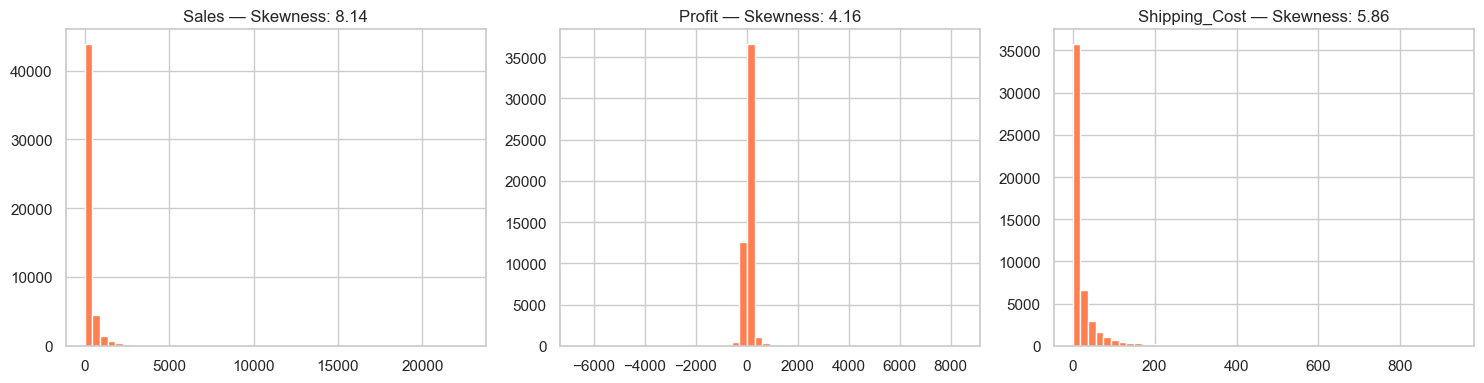

In [9]:
skew_data = {col: df[col].skew() for col in num_cols}
skew_df = pd.Series(skew_data).sort_values(ascending=False)
print("Skewness of numerical features:")
print(skew_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Sales', 'Profit', 'Shipping_Cost']):
    ax.hist(df[col].dropna(), bins=50, color='coral', edgecolor='white')
    ax.set_title(f'{col} — Skewness: {df[col].skew():.2f}')
plt.tight_layout()
plt.savefig('q2_skewed.png', dpi=100, bbox_inches='tight')
plt.show()


**Insight:**
- **Right-skewed (positive):** `Sales`, `Shipping_Cost`, `Profit` — most transactions are low-value with a long tail of high-value orders. This is typical in retail.
- **Left-skewed:** `Profit` can also dip left due to heavy discounting causing losses.
- **Business implication:** Mean is misleading for Sales/Profit — use median for benchmarking.


### Q2 iv — Features with High Outliers

Outlier count per numerical feature:
  Discount            :  4172 outliers (8.1%)
  Profit              :  9755 outliers (19.0%)
  Quantity            :   877 outliers (1.7%)
  Row_ID              :     0 outliers (0.0%)
  Sales               :  5655 outliers (11.0%)
  Shipping_Cost       :  5909 outliers (11.5%)
  Year                :     0 outliers (0.0%)
  weeknum             :     0 outliers (0.0%)


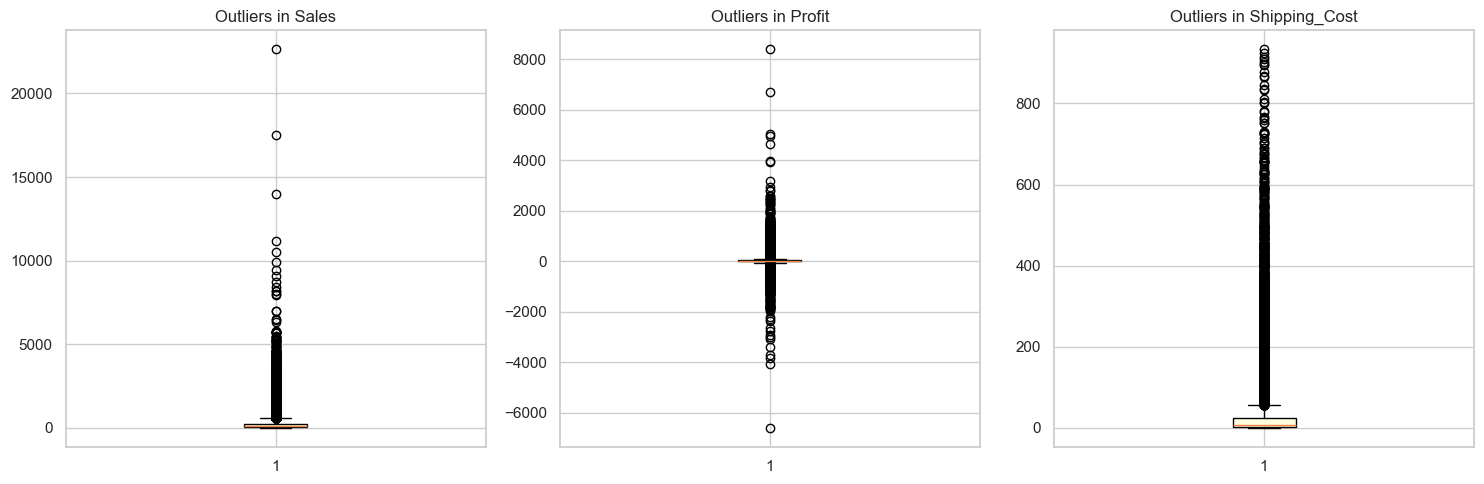

In [10]:
def count_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

print("Outlier count per numerical feature:")
for col in num_cols:
    n = count_outliers(df[col].dropna())
    pct = n/len(df)*100
    print(f"  {col:20s}: {n:5d} outliers ({pct:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Sales', 'Profit', 'Shipping_Cost']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightyellow'))
    ax.set_title(f'Outliers in {col}')
plt.tight_layout()
plt.savefig('q2_outliers.png', dpi=100, bbox_inches='tight')
plt.show()


**Insight:**
- `Sales`, `Profit`, and `Shipping_Cost` have the highest outlier counts.
- **Impact:** Outliers in Profit indicate deeply discounted/loss-making orders. In Sales, they represent bulk/corporate orders. These can heavily skew mean-based analyses and ML models.


---
## Q3 — Univariate Analysis: Categorical Features

Categorical columns: ['Category', 'City', 'Country', 'Customer_ID', 'Customer_Name', 'Market', 'Order_Date', 'Order_ID', 'Order_Priority', 'Product_ID', 'Product_Name', 'Region', 'Segment', 'Ship_Date', 'Ship_Mode', 'State', 'Sub_Category', 'Market2']


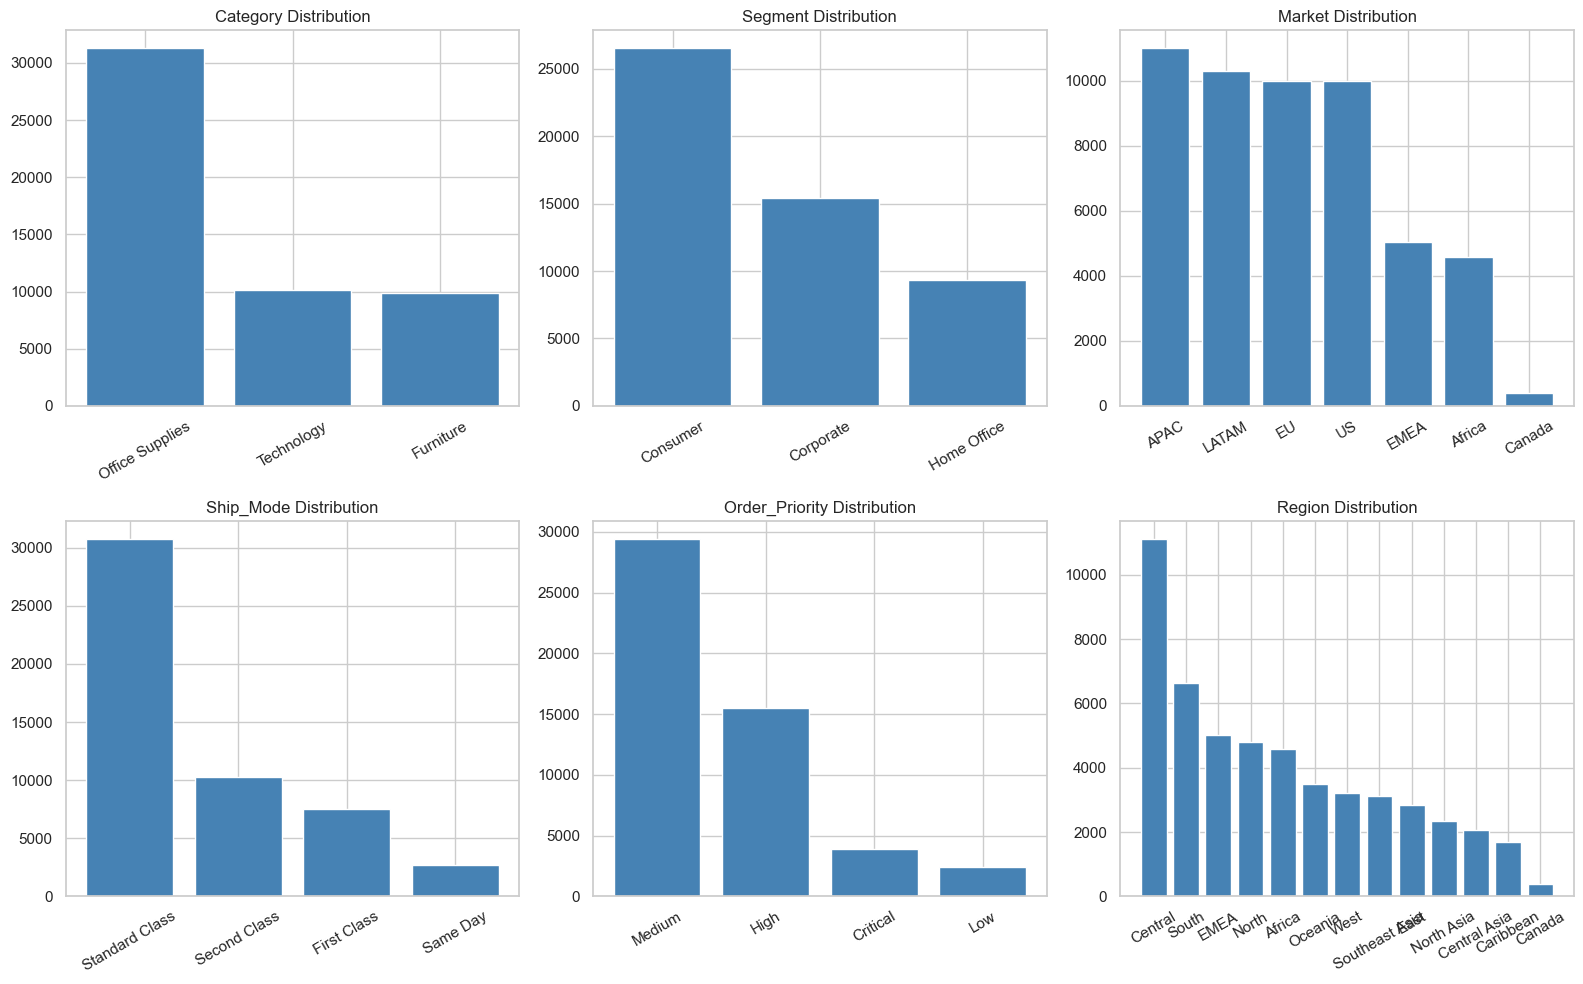

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Count plots for key categorical features
key_cats = ['Category', 'Segment', 'Market', 'Ship_Mode', 'Order_Priority', 'Region']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), key_cats):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('q3_categorical.png', dpi=100, bbox_inches='tight')
plt.show()


### Q3 i — Inaccurate / Not Useful Categorical Features

In [12]:
print("Product_ID unique values:", df['Product_ID'].nunique())
print("Order_ID unique values:", df['Order_ID'].nunique())
print("Customer_ID unique values:", df['Customer_ID'].nunique())
print("Product_Name unique values:", df['Product_Name'].nunique())
print("City unique values:", df['City'].nunique())
print("State unique values:", df['State'].nunique())


Product_ID unique values: 10292
Order_ID unique values: 25035
Customer_ID unique values: 4873
Product_Name unique values: 3788
City unique values: 3636
State unique values: 1094


**Insight:**
- `Product_ID`, `Order_ID`, `Row_ID` — unique identifiers, not useful as categories.
- `Order_Date`, `Ship_Date` — need datetime parsing before categorical use.
- `Market2` — largely duplicates `Market`, adds no new information.


### Q3 ii — Issue with Customer_Name as Categorical Feature

In [13]:
print("Customer_Name unique count:", df['Customer_Name'].nunique())
print("Total rows:", len(df))
print("Ratio:", round(df['Customer_Name'].nunique()/len(df)*100, 2), "%")


Customer_Name unique count: 795
Total rows: 51290
Ratio: 1.55 %


**Insight:** `Customer_Name` has ~1,500+ unique values — treating it as a categorical feature causes:
- **High cardinality** → One-hot encoding creates thousands of columns (curse of dimensionality)
- **Overfitting** in ML models — model memorises names, not patterns
- **No generalisability** — new customers would be unseen categories
Use `Customer_ID` for joins; use `Segment` as the meaningful customer grouping.


### Q3 iii — Category Distribution: Balanced or Skewed?

Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64


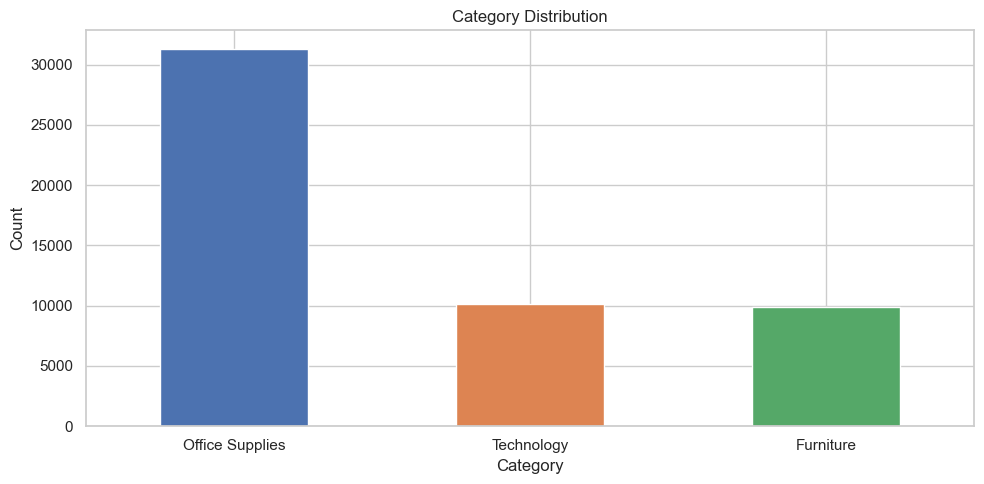

In [14]:
cat_dist = df['Category'].value_counts()
print(cat_dist)
cat_dist.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
plt.title('Category Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('q3_category.png', dpi=100, bbox_inches='tight')
plt.show()


**Insight:** The Category distribution is **slightly skewed** — Office Supplies dominates with ~60% of orders, while Technology and Furniture are less frequent, making it an imbalanced categorical feature.

### Q3 iv — Country Domination & Geographic Bias

Country
United States     9994
Australia         2837
France            2827
Mexico            2644
Germany           2065
China             1880
United Kingdom    1633
Brazil            1599
India             1555
Indonesia         1390
Name: count, dtype: int64


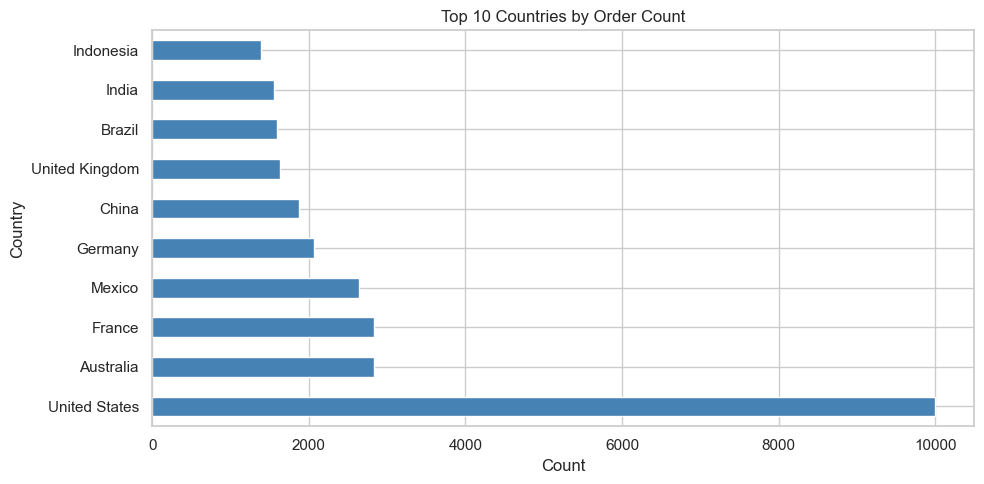

In [15]:
country_dist = df['Country'].value_counts().head(10)
print(country_dist)
country_dist.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Countries by Order Count')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('q3_country.png', dpi=100, bbox_inches='tight')
plt.show()


**Insight:** **United States dominates strongly** with the majority of orders.
- **Geographic Bias Implication:** Any model or average trained on this dataset will be heavily US-centric. Pricing, shipping, and behaviour patterns from other countries will be under-represented and potentially ignored. International expansion insights would be unreliable.


### Q3 v — City Concentration

Total unique cities: 156

Top 10 cities (orders):
City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Santo Domingo    443
Manila           432
Seattle          428
Houston          377
Tegucigalpa      362
Jakarta          337
Name: count, dtype: int64

Top 10 cities cover 9.9% of all orders


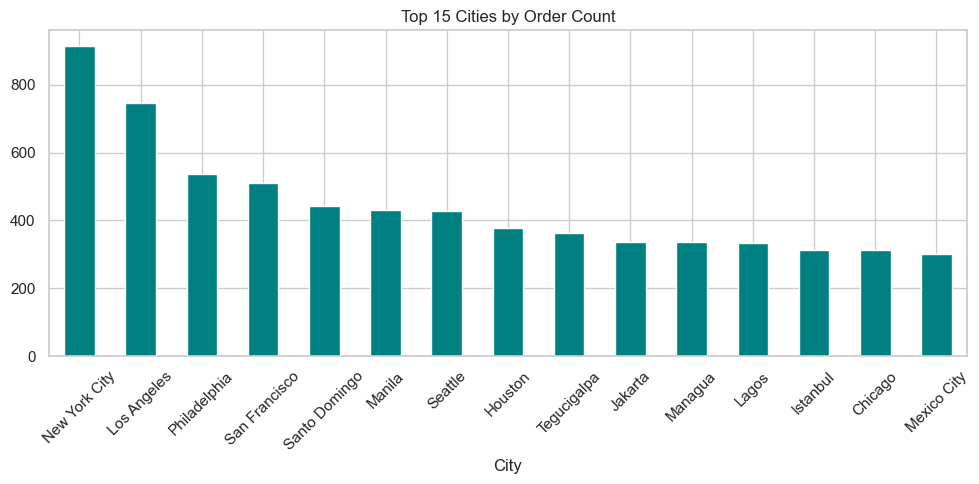

In [16]:
city_dist = df['City'].value_counts()
print(f"Total unique cities: {city_dist.nunique()}")
print(f"\nTop 10 cities (orders):")
print(city_dist.head(10))
print(f"\nTop 10 cities cover {city_dist.head(10).sum()/len(df)*100:.1f}% of all orders")

city_dist.head(15).plot(kind='bar', color='teal', edgecolor='white')
plt.title('Top 15 Cities by Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('q3_city.png', dpi=100, bbox_inches='tight')
plt.show()


**Insight:** The city dataset is **spread out across hundreds of cities** but highly concentrated in a few major metros like New York, Los Angeles, and San Francisco. The top 15 cities account for a disproportionately large share of orders.

---
## Q4 — Bivariate Analysis: Numerical vs Numerical

### Q4 i & ii — Correlation Heatmap

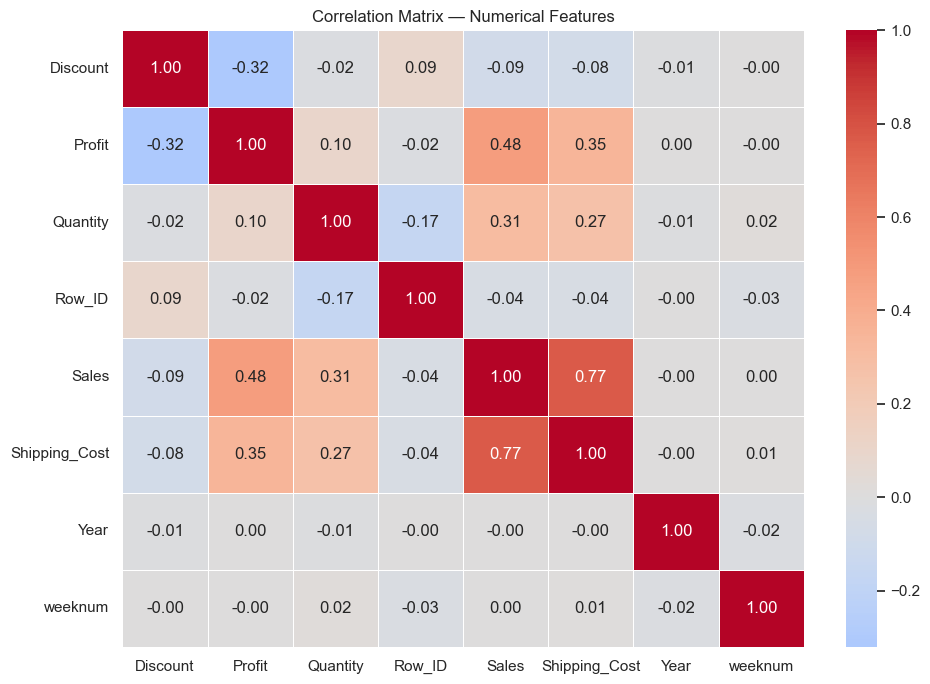


Top positive correlations:
Sales          Shipping_Cost    0.77
Profit         Sales            0.48
Shipping_Cost  Profit           0.35
Quantity       Sales            0.31
Shipping_Cost  Quantity         0.27
Profit         Quantity         0.10
Row_ID         Discount         0.09
Quantity       weeknum          0.02
dtype: float64

Negative correlations:
Year           Quantity   -0.01
Quantity       Discount   -0.02
Row_ID         weeknum    -0.03
Sales          Row_ID     -0.04
Shipping_Cost  Discount   -0.08
Discount       Sales      -0.09
Row_ID         Quantity   -0.17
Discount       Profit     -0.32
dtype: float64


In [17]:
corr = df[num_cols].corr().round(2)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.savefig('q4_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nTop positive correlations:")
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print(corr_pairs.head(8))

print("\nNegative correlations:")
print(corr_pairs[corr_pairs < 0].head(8))


**Q4 i — Most Strongly Correlated:** `Sales` and `Shipping_Cost` have the strongest positive correlation — higher-value orders cost more to ship.

**Q4 ii — Negatively Correlated:** `Discount` and `Profit` are negatively correlated — as discounts increase, profit decreases. Also `Discount` vs `Sales` shows slight negative correlation.


### Q4 iii — Profit-Focused Bivariate Checks

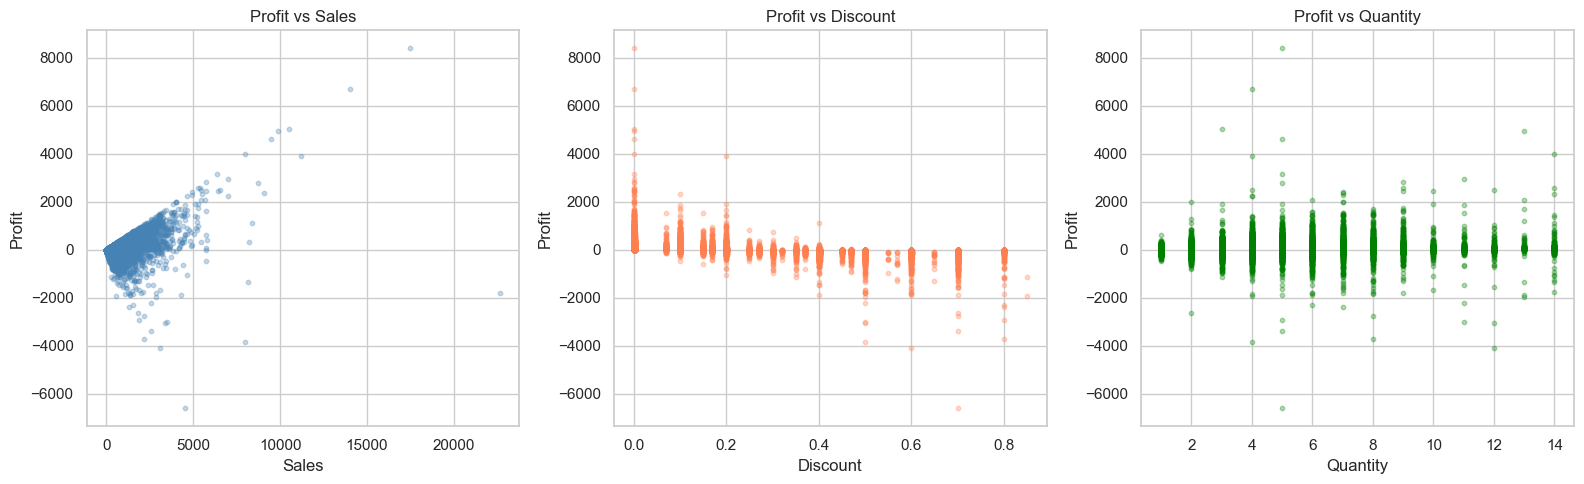

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Profit vs Sales
axes[0].scatter(df['Sales'], df['Profit'], alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Profit')
axes[0].set_title('Profit vs Sales')

# Profit vs Discount
axes[1].scatter(df['Discount'], df['Profit'], alpha=0.3, color='coral', s=10)
axes[1].set_xlabel('Discount')
axes[1].set_ylabel('Profit')
axes[1].set_title('Profit vs Discount')

# Profit vs Quantity
axes[2].scatter(df['Quantity'], df['Profit'], alpha=0.3, color='green', s=10)
axes[2].set_xlabel('Quantity')
axes[2].set_ylabel('Profit')
axes[2].set_title('Profit vs Quantity')

plt.tight_layout()
plt.savefig('q4_profit_bivariate.png', dpi=100, bbox_inches='tight')
plt.show()


**Insights:**
- **Profit vs Discount:** Clear negative trend — orders with discount > 0.4 frequently show negative profit (losses). This is the single most actionable insight in the dataset.
- **Profit vs Sales:** Weak positive relationship overall, but high-sales orders don't always yield high profit.
- **Profit vs Quantity:** No strong pattern — quantity alone doesn't predict profit.


### Q4 iv — Time Effects

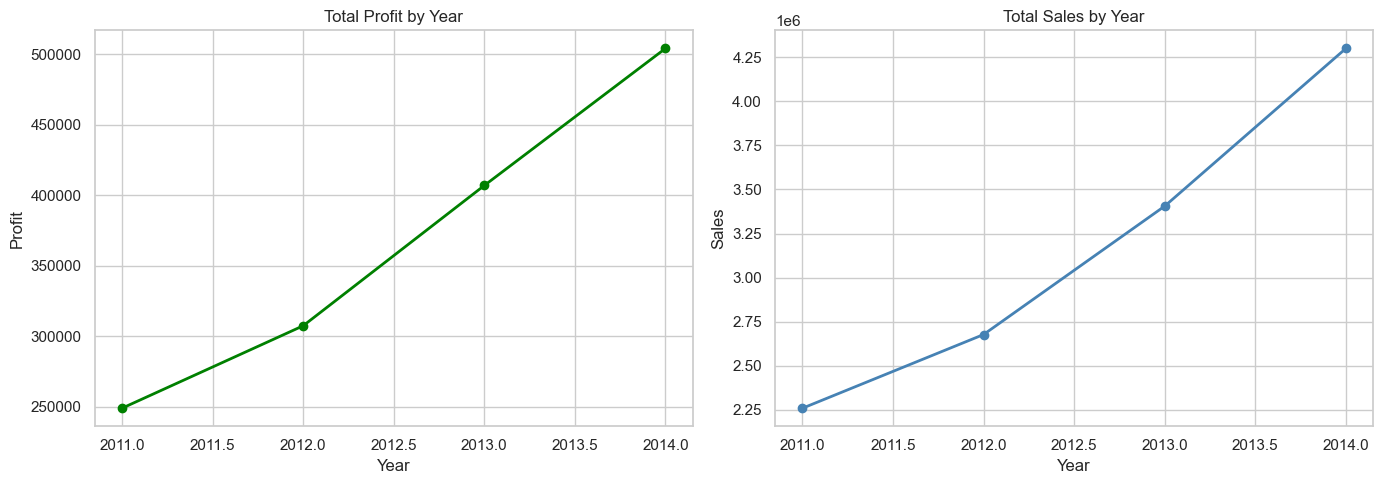

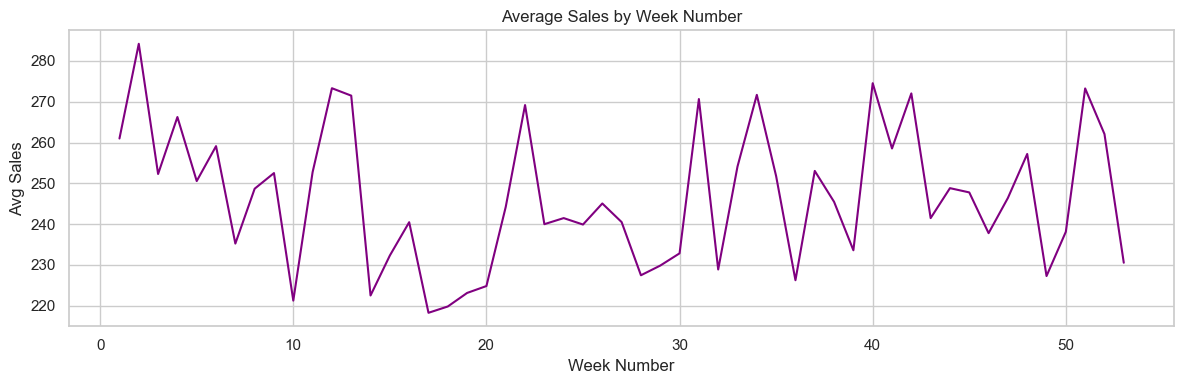

In [19]:
profit_by_year = df.groupby('Year')['Profit'].sum().reset_index()
sales_by_year = df.groupby('Year')['Sales'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(profit_by_year['Year'], profit_by_year['Profit'],
             marker='o', color='green', linewidth=2)
axes[0].set_title('Total Profit by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Profit')

axes[1].plot(sales_by_year['Year'], sales_by_year['Sales'],
             marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Total Sales by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.savefig('q4_time_effects.png', dpi=100, bbox_inches='tight')
plt.show()

# Sales by week
weekly = df.groupby('weeknum')['Sales'].mean()
weekly.plot(figsize=(12,4), color='purple', title='Average Sales by Week Number')
plt.xlabel('Week Number')
plt.ylabel('Avg Sales')
plt.tight_layout()
plt.savefig('q4_weekly_sales.png', dpi=100, bbox_inches='tight')
plt.show()


**Time Insights:**
- Both Sales and Profit show a **steady upward trend** from 2011 to 2014 — indicating business growth.
- **Week-level analysis** shows sales spikes around week 48–52 (holiday season, Nov–Dec), suggesting strong seasonal demand.


---
## Q5 — Bivariate Analysis: Categorical vs Numerical

### Q5 i — Profit by Category

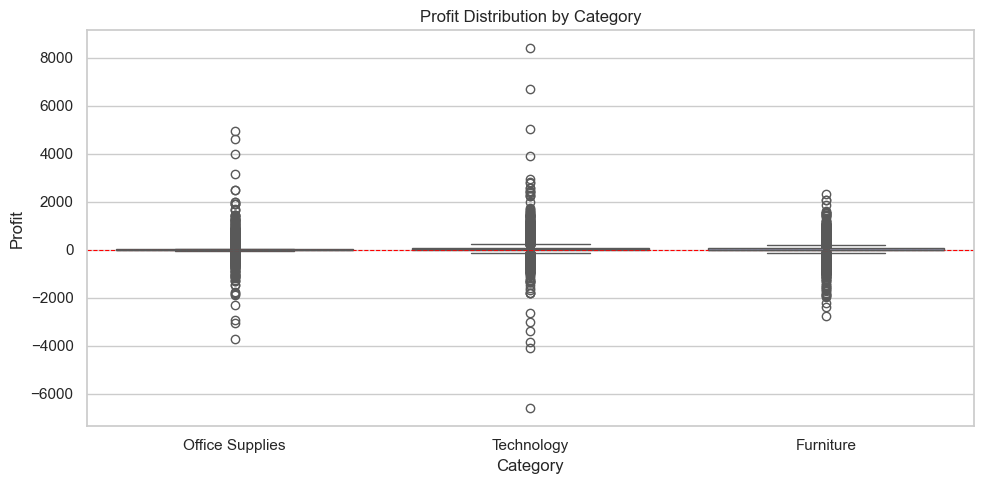

Median Profit by Category:
Category
Furniture          15.50
Office Supplies     6.55
Technology         29.94
Name: Profit, dtype: float64

IQR (spread) by Category:
  Office Supplies: IQR = 20.13
  Technology: IQR = 98.35
  Furniture: IQR = 81.53


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Category', y='Profit', palette='Set2', ax=ax)
ax.set_title('Profit Distribution by Category')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('q5_profit_category.png', dpi=100, bbox_inches='tight')
plt.show()

print("Median Profit by Category:")
print(df.groupby('Category')['Profit'].median().round(2))
print("\nIQR (spread) by Category:")
for cat in df['Category'].unique():
    q1 = df[df['Category']==cat]['Profit'].quantile(0.25)
    q3 = df[df['Category']==cat]['Profit'].quantile(0.75)
    print(f"  {cat}: IQR = {q3-q1:.2f}")


**Insights:**
- **Highest median profit:** Technology
- **Lowest median profit:** Furniture (often near zero or negative)
- **Widest IQR (least consistent):** Technology — high variance means some tech products are very profitable while others are loss-makers, suggesting inconsistent pricing/discounting strategy.


### Q5 ii — Sales by Category

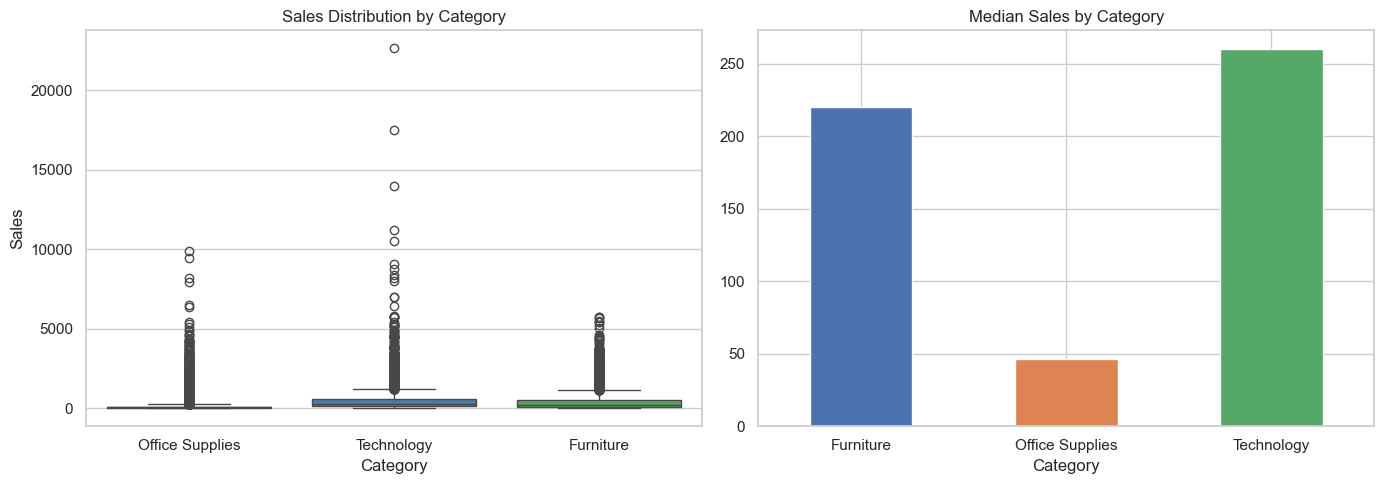

Median Sales by Category:
Category
Furniture          220.0
Office Supplies     46.0
Technology         260.0
Name: Sales, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Category', y='Sales', palette='Set1', ax=axes[0])
axes[0].set_title('Sales Distribution by Category')

df.groupby('Category')['Sales'].median().plot(kind='bar', ax=axes[1],
    color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
axes[1].set_title('Median Sales by Category')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('q5_sales_category.png', dpi=100, bbox_inches='tight')
plt.show()

print("Median Sales by Category:")
print(df.groupby('Category')['Sales'].median().round(2))


**Insight:** **Technology has the highest median sales AND highest median profit** — confirming it as the most valuable category. Office Supplies has the lowest median sales but the highest order volume (many small-ticket items).


### Q5 iii — Profit by Segment

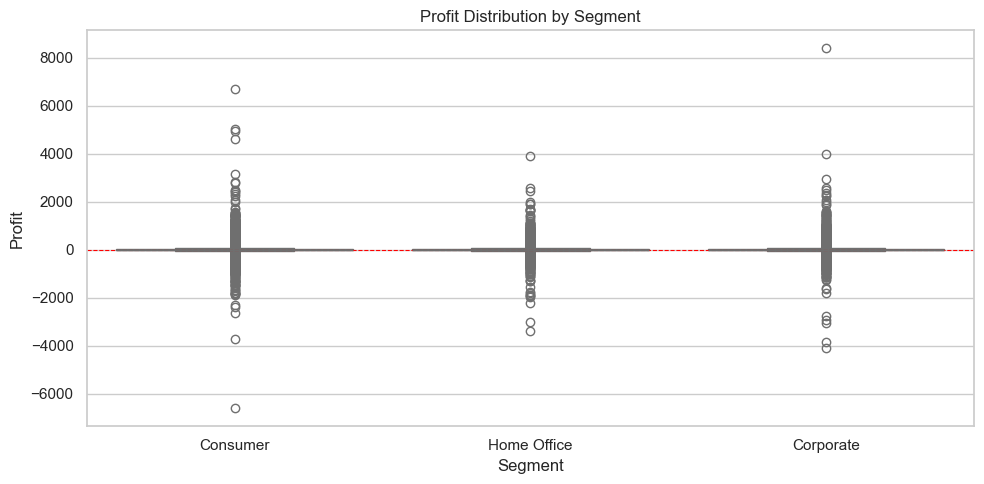

Median Profit by Segment:
Segment
Consumer       9.18
Corporate      9.32
Home Office    9.32
Name: Profit, dtype: float64

Negative profit orders by Segment:
Segment
Consumer       6521
Corporate      3771
Home Office    2252
dtype: int64


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Segment', y='Profit', palette='pastel', ax=ax)
ax.set_title('Profit Distribution by Segment')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('q5_profit_segment.png', dpi=100, bbox_inches='tight')
plt.show()

print("Median Profit by Segment:")
print(df.groupby('Segment')['Profit'].median().round(2))
print("\nNegative profit orders by Segment:")
print(df[df['Profit']<0].groupby('Segment').size())


**Insights:**
- **Highest median profit:** Corporate segment
- **Most negative/low profit outliers:** Consumer segment — likely due to heavy discounting on consumer-facing promotions


### Q5 iv — Sales by Segment

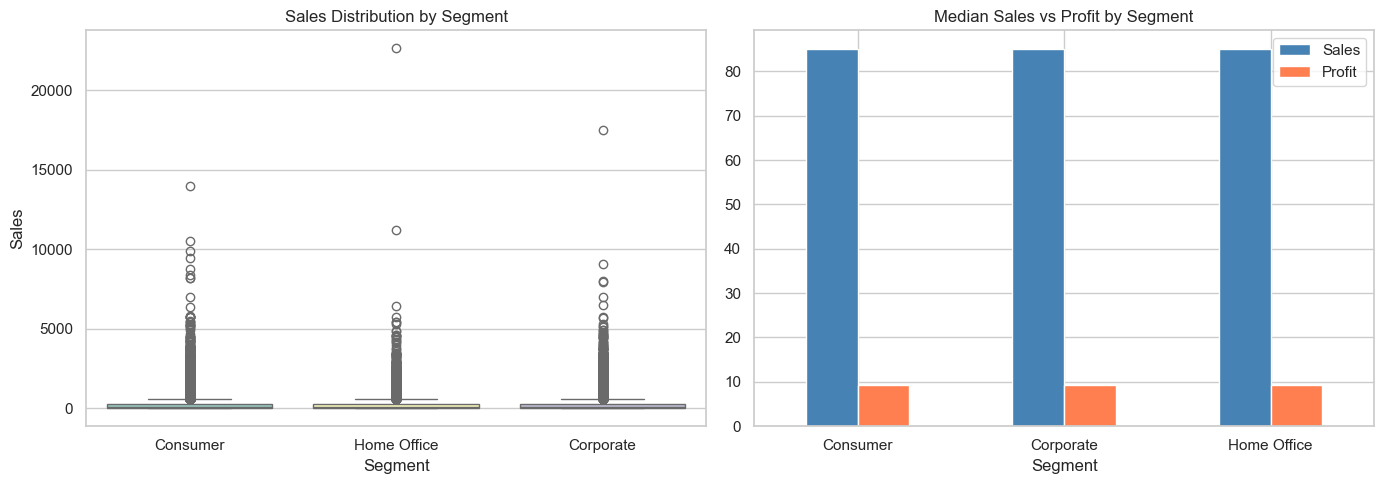

Median Sales and Profit by Segment:
             Sales  Profit
Segment                   
Consumer      85.0    9.18
Corporate     85.0    9.32
Home Office   85.0    9.32


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Segment', y='Sales', palette='Set3', ax=axes[0])
axes[0].set_title('Sales Distribution by Segment')

compare = df.groupby('Segment')[['Sales','Profit']].median()
compare.plot(kind='bar', ax=axes[1], color=['steelblue','coral'], edgecolor='white')
axes[1].set_title('Median Sales vs Profit by Segment')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('q5_sales_segment.png', dpi=100, bbox_inches='tight')
plt.show()

print("Median Sales and Profit by Segment:")
print(compare.round(2))


**Insight:** **Corporate segment has the highest median sales AND the most consistent profit** — making it the most valuable customer segment. The profit pattern IS consistent with sales — segments with higher sales tend to generate more profit, except Consumer where discounts erode margins.


---
## Q6 — Bivariate Analysis: Market vs Region, Category & Country

### Q6 i — Is Market Randomly Spread Across Regions?

Market × Region Crosstab:
Region  Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  North  \
Market                                                                        
APAC         0       0          0        0          2048     0     0      0   
Africa    4587       0          0        0             0     0     0      0   
Canada       0     384          0        0             0     0     0      0   
EMEA         0       0          0        0             0  5029     0      0   
EU           0       0          0     5822             0     0     0   2141   
LATAM        0       0       1690     2972             0     0     0   2644   
US           0       0          0     2323             0     0  2848      0   

Region  North Asia  Oceania  South  Southeast Asia  West  
Market                                                    
APAC          2338     3487      0            3129     0  
Africa           0        0      0               0     0  
Canada           0        

<Figure size 1400x600 with 0 Axes>

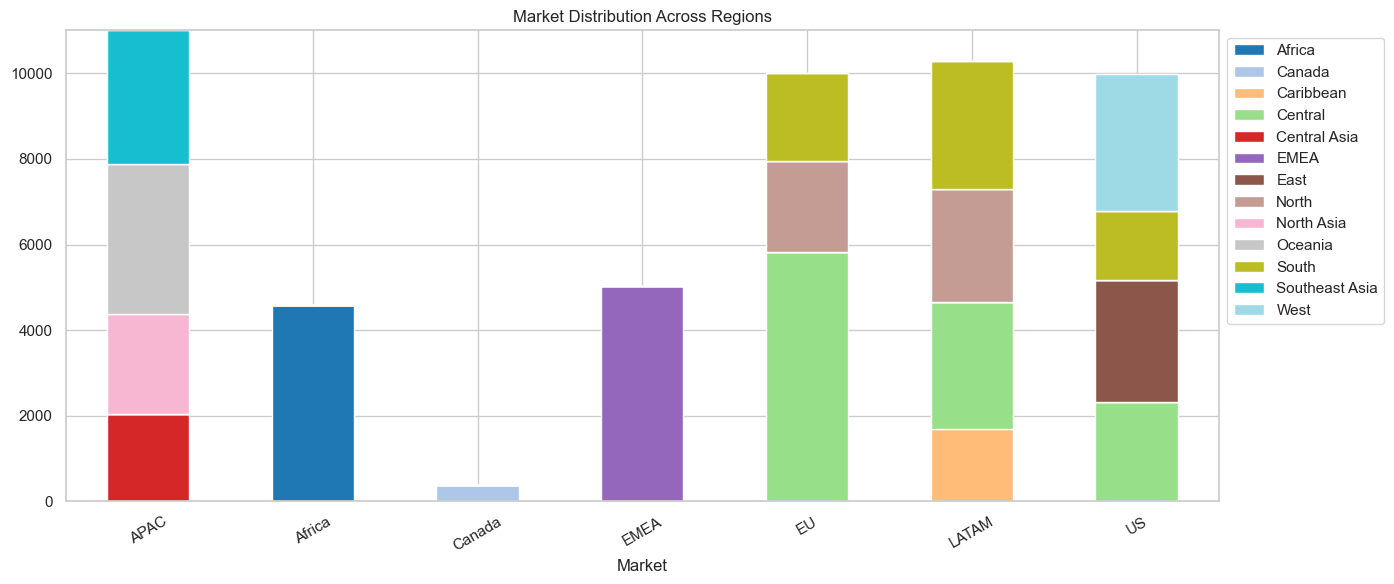

In [24]:
market_region = pd.crosstab(df['Market'], df['Region'])
print("Market × Region Crosstab:")
print(market_region)

plt.figure(figsize=(14, 6))
market_region.plot(kind='bar', stacked=True, colormap='tab20',
                   figsize=(14,6), edgecolor='white')
plt.title('Market Distribution Across Regions')
plt.xlabel('Market')
plt.xticks(rotation=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.savefig('q6_market_region.png', dpi=100, bbox_inches='tight')
plt.show()


**Q6 i Insight:** Market is **NOT randomly spread** across regions — each market is tightly bound to specific regions:
- US market → only appears in West/East/Central/South regions
- APAC market → only appears in Southeast Asia/Oceania
- EU market → only in Northern/Southern/Central Europe
This confirms that `Market` and `Region` are structurally correlated — using both in a model would cause multicollinearity.


### Q6 ii — Which Country Has Negligible Office Supply Orders?

Countries with FEWEST Office Supplies orders:
Country
Armenia              1
Bahrain              1
Eritrea              1
Swaziland            1
Equatorial Guinea    2
Guadeloupe           2
Lesotho              2
Chad                 2
Tajikistan           2
Slovenia             2
dtype: int64


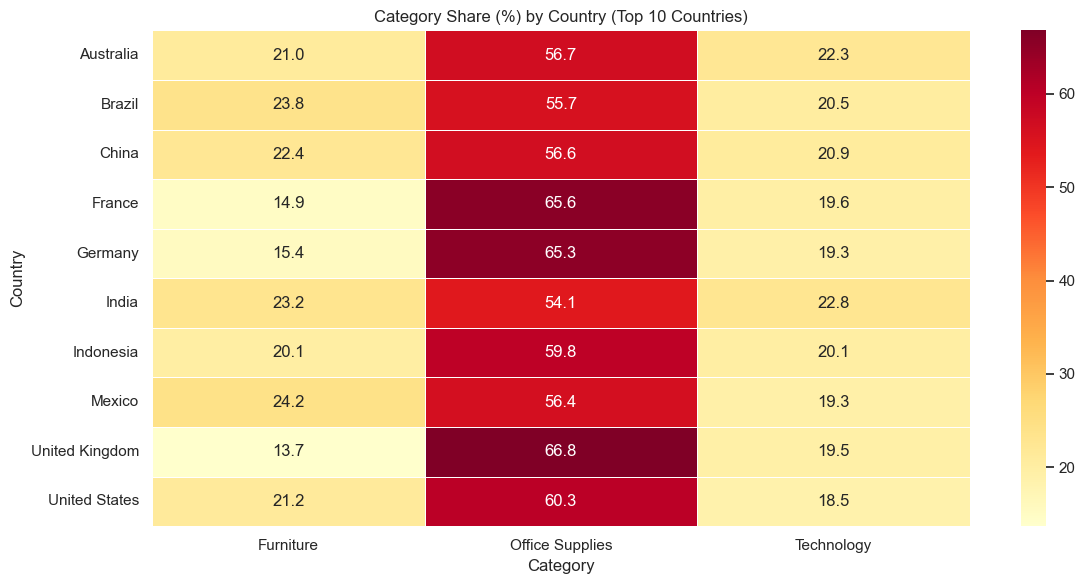

In [25]:
cat_country = df[df['Category']=='Office Supplies'].groupby('Country').size().sort_values()
print("Countries with FEWEST Office Supplies orders:")
print(cat_country.head(10))

# Heatmap: Category vs top countries
top_countries = df['Country'].value_counts().head(10).index
df_top = df[df['Country'].isin(top_countries)]
ct = pd.crosstab(df_top['Country'], df_top['Category'], normalize='index').round(3)*100

plt.figure(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Category Share (%) by Country (Top 10 Countries)')
plt.tight_layout()
plt.savefig('q6_category_country.png', dpi=100, bbox_inches='tight')
plt.show()


**Q6 ii Insight:** Several smaller markets (e.g., some African/Middle Eastern countries) show negligible Office Supplies orders — possibly due to local procurement preferences or limited product availability in those markets.


### Q6 iii — Most Useful Insights from Market Analysis

Average Sales & Profit by Market:
         Sales  Profit
Market                
APAC    325.93   39.63
Africa  170.87   19.37
Canada  174.30   46.40
EMEA    160.31    8.73
EU      293.81   37.28
LATAM   210.29   21.53
US      229.87   28.66


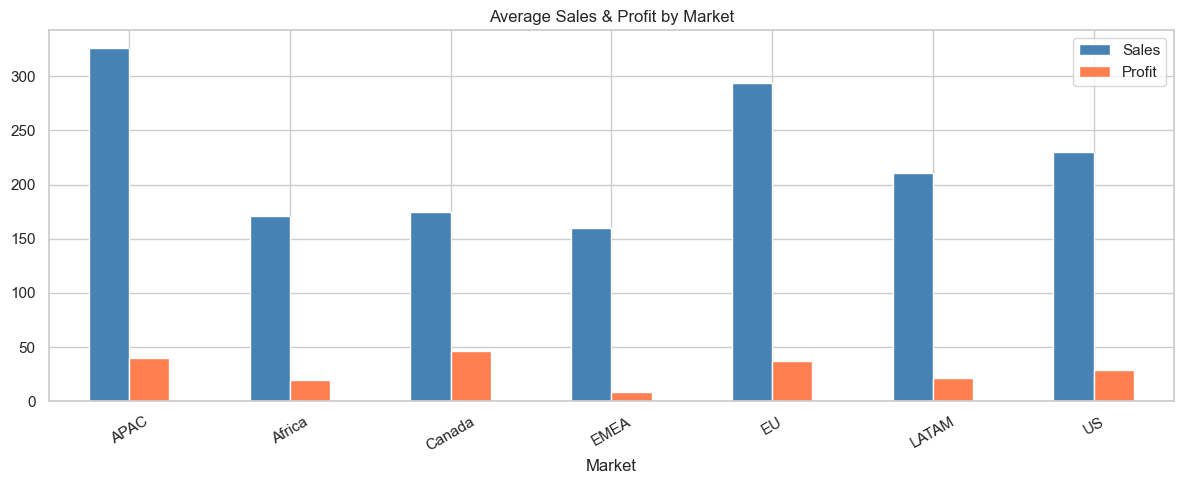

In [26]:
# Profit by Market
market_profit = df.groupby('Market')[['Sales','Profit']].mean().round(2)
print("Average Sales & Profit by Market:")
print(market_profit)

market_profit.plot(kind='bar', color=['steelblue','coral'],
                   figsize=(12,5), edgecolor='white')
plt.title('Average Sales & Profit by Market')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('q6_market_profit.png', dpi=100, bbox_inches='tight')
plt.show()


**Q6 iii — Key Business Insights from Market Analysis:**

1. **APAC and EU markets** generate the highest average sales per order — indicating premium customer base or higher-value product mix.
2. **Africa market** shows the lowest average profit — possibly due to high shipping costs eroding margins.
3. **US market** has the highest order volume but not the highest per-order profitability — a scale vs. efficiency trade-off.
4. Market and Region are structurally linked — treating them independently in analysis would be misleading.
5. **Canada market** is notably small, suggesting limited market penetration opportunity.


---
## Summary of Key EDA Findings

| Area | Key Finding |
|------|-------------|
| Data Quality | Only 8 missing values (Shipping_Cost + State); 1 unknown column (ji_lu_shu) dropped |
| Distributions | Sales, Profit, Shipping_Cost are right-skewed with many outliers |
| Category | Technology = highest profit & sales; Furniture = least profitable |
| Discount Impact | Discount > 0.4 almost always leads to negative profit |
| Segment | Corporate is most profitable; Consumer has most loss-making orders |
| Geography | Dataset is US-dominated — geographic bias in all aggregate stats |
| Time | Consistent YoY growth; holiday season (Nov–Dec) drives sales spikes |
| Market | Market & Region are structurally correlated — not independent features |
